In [2]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# load data and filter during growing season
df = pyreadr.read_r("/glade/derecho/scratch/brendanc/VPD/Data_TreeNet_daily.rds")[None]
df = df[(df.doy >= 91) & (df.doy <= 273)].copy()

# select species
mask = (df.species.str.lower() == "quercus petraea")
df = df.loc[mask].copy()

# transform growth vs non growth to 1 and 0 for binomial GLM
df["grow"] = (df["dGRO.yr"] > 0).astype(int)

# list of independent variables
predictors = ["temp", "vpd", "rad", "total_precip", "swp", "Daylength"]

# drop nans
work = df[["grow", "station"] + predictors].dropna().copy()

# compute means and SDs, drop zero-variance predictors
sd = work[predictors].std()
zero_vars = sd[sd == 0.0].index.tolist()
if zero_vars:
    print("Dropping constant predictors:", zero_vars)
    predictors = [v for v in predictors if v not in zero_vars]

# standardize remaining predictors
work[predictors] = (work[predictors] - work[predictors].mean()) / work[predictors].std()

# VIF filtering
VIF_THRESHOLD = 5.0

def compute_vif(df, cols):
    X = df[cols].values
    return pd.Series(
        [variance_inflation_factor(X, i) for i in range(len(cols))],
        index=cols
    )
vif_predictors = predictors.copy()
while True:
    vif = compute_vif(work, vif_predictors)
    print("VIF:\n", vif.round(2))
    if vif.max() <= VIF_THRESHOLD:
        break
    drop = vif.idxmax()
    vif_predictors.remove(drop)

predictors = vif_predictors
print("Predictors after VIF filtering:", predictors)

# construct formula 
base = [v for v in predictors if v != "Daylength"]
rhs = "Daylength*(" + "+".join(base) + ")" if "Daylength" in predictors else "+".join(base)
if "vpd" in predictors and "swp" in predictors:
    rhs += " + vpd:swp"
formula = "grow ~ " + rhs
print("Model formula:", formula)

# covariance type
stations = work["station"].unique()
if len(stations) > 1:
    cov_type = "cluster"
    cov_kwds = {"groups": work["station"]}
else:
    cov_type = "HC0"
    cov_kwds = {}

# fit the GLM
glm = smf.glm(formula, data=work, family=sm.families.Binomial()) \
        .fit(cov_type=cov_type, cov_kwds=cov_kwds)

print(glm.summary())

VIF:
 temp            2.82
vpd             3.74
rad             2.60
total_precip    1.35
swp             1.35
Daylength       1.51
dtype: float64
Predictors after VIF filtering: ['temp', 'vpd', 'rad', 'total_precip', 'swp', 'Daylength']
Model formula: grow ~ Daylength*(temp+vpd+rad+total_precip+swp) + vpd:swp
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   grow   No. Observations:                 9011
Model:                            GLM   Df Residuals:                     8998
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4638.4
Date:                Wed, 06 May 2026   Deviance:                       9276.8
Time:                        09:20:03   Pearson chi2:                 9.43e+03
No. Iterations:                     8   Pseudo R-squ. (C

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Build training data in raw units
predictors = ["vpd","temp","rad","total_precip","swp","Daylength"]
cols = ["grow","station"] + predictors
work_raw = df[cols].dropna().copy()
for c in predictors:
    work_raw[c] = pd.to_numeric(work_raw[c], errors="coerce")
work_raw = work_raw.dropna(subset=predictors + ["grow"])

#species, swp filter, vpd filter, vpd dof, swp dof
#picea abies: none, none, 5, 3
#abies alba: -450, none, 5, 3
#pinus sylvestris: -1750, none, 5, 3
#fagus sylvatica: none, none, 5, 3
#quercus petraea: none, none, 4, 3
#fraxinus excelsior: none, none, 5, 3
#quercus pubescens: -1750, none, 4, 3

#fit_mask = work_raw["swp"] >= -1750.0
#work_raw = work_raw.loc[fit_mask].copy()
#fit_mask = work_raw["vpd"] <= 1.77
#work_raw = work_raw.loc[fit_mask].copy()

#fit_mask = work_raw["vpd"] >= 0.2
#work_raw = work_raw.loc[fit_mask].copy()

y = work_raw["grow"].astype(float).to_numpy()
X = work_raw[predictors].reset_index(drop=True)

# 2) Standardize before VIF filtering
X_std = (X - X.mean()) / X.std()

VIF_THRESHOLD = 5.0
def compute_vif(df, cols):
    arr = df[cols].values
    return pd.Series(
        [variance_inflation_factor(arr, i) for i in range(len(cols))],
        index=cols
    )
vif_predictors = predictors.copy()
while True:
    vif = compute_vif(X_std, vif_predictors)
    print("VIF:\n", vif.round(2))
    if vif.max() <= VIF_THRESHOLD:
        break
    drop = vif.idxmax()
    print(f"Dropping {drop} (VIF={vif[drop]:.2f})")
    vif_predictors.remove(drop)

predictors = vif_predictors
print("Predictors after VIF filtering:", predictors)

# Revert to raw units for spline fitting
X = X[predictors].reset_index(drop=True)

# Natural cubic splines on vpd and swp 
exog_parts = []
linear_cols = [v for v in predictors if v not in ("vpd", "swp")]

if "vpd" in predictors:
    s_vpd = dmatrix(f"cr(vpd, df={4}) - 1", data=X, return_type="dataframe")
    design_vpd = s_vpd.design_info
    exog_parts.append(s_vpd.reset_index(drop=True))

if "swp" in predictors:
    s_swp = dmatrix(f"cr(swp, df={3}) - 1", data=X, return_type="dataframe")
    design_swp = s_swp.design_info
    exog_parts.append(s_swp.reset_index(drop=True))

if linear_cols:
    X_lin = X[linear_cols].reset_index(drop=True)
    exog_parts.append(X_lin)

# Full design matrix
EXOG = pd.concat(exog_parts, axis=1)
all_col_names = list(EXOG.columns)                                    # ← add
vpd_col_names = [c for c in all_col_names if c.startswith("cr(vpd")] # ← add
swp_col_names = [c for c in all_col_names if c.startswith("cr(swp")] # ← add

# Fit the GLM (Binomial logit), with clustered SE by station if >1
if work_raw["station"].nunique() > 1:
    cov_type = "cluster"
    cov_kwds = {"groups": work_raw["station"].values}
else:
    cov_type = "HC0"
    cov_kwds = {}

glm_ns = sm.GLM(y, EXOG.values, family=sm.families.Binomial()).fit(
    cov_type=cov_type, cov_kwds=cov_kwds
)
print(glm_ns.summary())


VIF:
 vpd             3.74
temp            2.82
rad             2.60
total_precip    1.35
swp             1.35
Daylength       1.51
dtype: float64
Predictors after VIF filtering: ['vpd', 'temp', 'rad', 'total_precip', 'swp', 'Daylength']
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 9011
Model:                            GLM   Df Residuals:                     9001
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4729.2
Date:                Wed, 06 May 2026   Deviance:                       9458.3
Time:                        09:20:03   Pearson chi2:                 8.39e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2323
Covariance Type:              cluster              

In [5]:
# New GLMs from 95% confidence interval of VPD
vpd_idx = [all_col_names.index(c) for c in vpd_col_names]

glm_ns_standard = sm.GLM(y, glm_ns.model.exog, family=sm.families.Binomial()).fit()
se_vpd = np.sqrt(np.diag(glm_ns_standard.cov_params()))[vpd_idx]

vpd_coefs     = glm_ns.params[vpd_idx]
vpd_magnitude = np.mean(np.abs(vpd_coefs))
vpd_se_mean   = np.mean(se_vpd)

glm_ns_minvpd = sm.GLM(y, glm_ns.model.exog, family=sm.families.Binomial()).fit(
    cov_type=cov_type, cov_kwds=cov_kwds)
glm_ns_minvpd.params[:] = glm_ns.params.copy()
glm_ns_minvpd.params[vpd_idx] *= (1 + 1.96 * vpd_se_mean / vpd_magnitude)  # stronger suppression

glm_ns_maxvpd = sm.GLM(y, glm_ns.model.exog, family=sm.families.Binomial()).fit(
    cov_type=cov_type, cov_kwds=cov_kwds)
glm_ns_maxvpd.params[:] = glm_ns.params.copy()
glm_ns_maxvpd.params[vpd_idx] *= (1 - 1.96 * vpd_se_mean / vpd_magnitude)  # weaker suppression

assert len(glm_ns_minvpd.params) == len(glm_ns.params), "minvpd param mismatch!"
assert len(glm_ns_maxvpd.params) == len(glm_ns.params), "maxvpd param mismatch!"
print(f"All GLMs have {len(glm_ns.params)} params — glm_ns_minvpd and glm_ns_maxvpd ready")

All GLMs have 11 params — glm_ns_minvpd and glm_ns_maxvpd ready


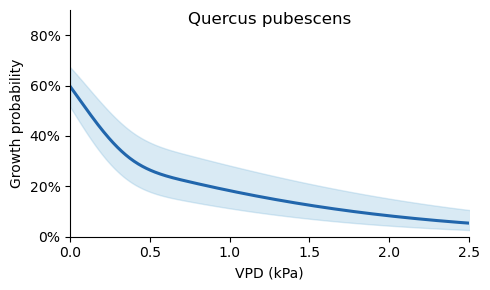

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from patsy import build_design_matrices

# VPD grid
VPD_GRID = np.linspace(X["vpd"].min(), X["vpd"].max(), 300)
mean_vals = X.mean().to_dict()
grid_df = pd.DataFrame({col: [mean_vals[col]] * len(VPD_GRID) for col in X.columns})
grid_df["vpd"] = VPD_GRID

grid_parts = []
if "vpd" in predictors:
    g_vpd = build_design_matrices([s_vpd.design_info],
                                   {"vpd": grid_df["vpd"].values},
                                   return_type="dataframe")[0]
    grid_parts.append(g_vpd.reset_index(drop=True))
if "swp" in predictors:
    g_swp = build_design_matrices([s_swp.design_info],
                                   {"swp": grid_df["swp"].values},
                                   return_type="dataframe")[0]
    grid_parts.append(g_swp.reset_index(drop=True))
if linear_cols:
    grid_parts.append(grid_df[linear_cols].reset_index(drop=True))

EXOG_grid = pd.concat(grid_parts, axis=1).values

def inv_logit(x):
    return 1.0 / (1.0 + np.exp(-x))

prob_central = inv_logit(EXOG_grid @ glm_ns.params)
prob_min     = inv_logit(EXOG_grid @ glm_ns_minvpd.params)
prob_max     = inv_logit(EXOG_grid @ glm_ns_maxvpd.params)

# Plot 
fig, ax = plt.subplots(figsize=(5, 3))
ax.fill_between(VPD_GRID, prob_min, prob_max, color="#6baed6", alpha=0.25)
ax.plot(VPD_GRID, prob_central, color="#2166ac", lw=2.2)
ax.set_xlabel("VPD (kPa)", fontsize=10)
ax.set_ylabel("Growth probability", fontsize=10)
ax.set_title("Quercus pubescens", fontsize=12, y=0.90)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 0.9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

savedir = '/glade/derecho/scratch/brendanc/fates_output/constco2/GRL_figures'
#plt.savefig(
#    savedir + "/quercus_pubescens_vpd.png",
#    dpi=600, bbox_inches="tight", pad_inches=0.05
#)
plt.show()

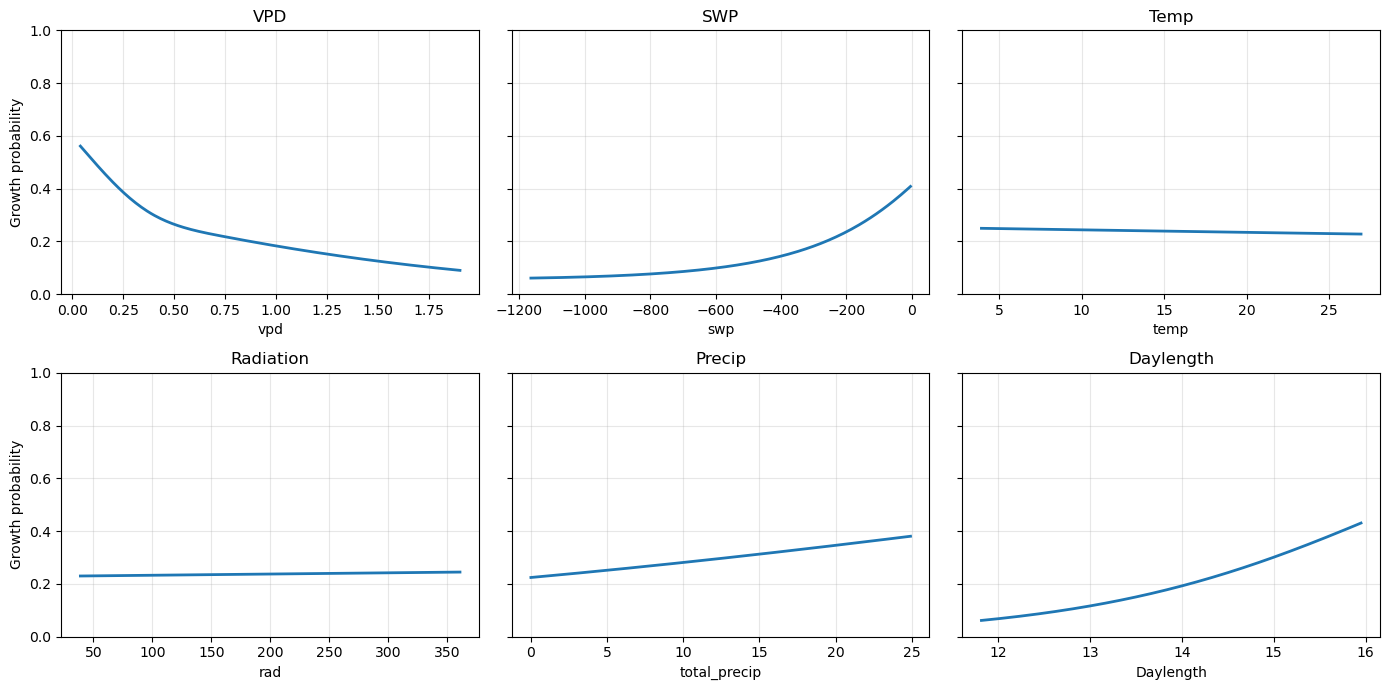

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patsy import build_design_matrices

# - glm_ns        : fitted statsmodels GLM
# - design_vpd    : patsy DesignInfo for vpd spline
# - design_swp    : patsy DesignInfo for swp spline
# - X             : training DataFrame with raw predictors
#
# Training order: [vpd splines][swp splines][temp, rad, total_precip, Daylength]

spline_vars = ["vpd", "swp"]
linear_vars = ["temp", "rad", "total_precip", "Daylength"]
all_vars    = spline_vars + linear_vars

designs = {"vpd": design_vpd, "swp": design_swp}

# Reference context (means of training data)
ref = X[all_vars].mean()

def _build_exog(df_pred):
    """Rebuild EXOG in the SAME column order used during training."""
    blocks = []
    for var in spline_vars:
        [B] = build_design_matrices([designs[var]], df_pred)
        blocks.append(np.asarray(B))
    blocks.append(df_pred[linear_vars].to_numpy())
    return np.column_stack(blocks)

def _predict_curve(var, n=200, use_quantiles=True):
    """Predict growth probability while varying a spline var."""
    if use_quantiles:
        lo, hi = X[var].quantile([0.01,0.99]).to_numpy()
    else:
        lo, hi = X[var].min(), X[var].max()
    grid = np.linspace(lo, hi, n)
    df_pred = pd.DataFrame({v: np.full_like(grid, ref[v], dtype=float) for v in all_vars})
    df_pred[var] = grid
    EXOG_new = _build_exog(df_pred)
    yhat = glm_ns.predict(EXOG_new)
    return grid, yhat

def _predict_line(var, n=200, use_quantiles=True):
    """Predict growth probability while varying a linear var."""
    if use_quantiles:
        lo, hi = X[var].quantile([0.01,0.99]).to_numpy()
    else:
        lo, hi = X[var].min(), X[var].max()
    grid = np.linspace(lo, hi, n)
    df_pred = pd.DataFrame({v: np.full_like(grid, ref[v], dtype=float) for v in all_vars})
    df_pred[var] = grid
    EXOG_new = _build_exog(df_pred)
    yhat = glm_ns.predict(EXOG_new)
    return grid, yhat

# Plot curves (vpd, swp) and lines (temp, rad, precip, daylength)
vars_to_plot = spline_vars + linear_vars
titles = {
    "vpd": "VPD",
    "swp": "SWP",
    "temp": "Temp",
    "rad": "Radiation",
    "total_precip": "Precip",
    "Daylength": "Daylength"
}

nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14,7), sharey=True)
axes = axes.ravel()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    if var in spline_vars:
        x, y = _predict_curve(var)
        ax.plot(x, y, lw=2)
    else:
        x, y = _predict_line(var)
        ax.plot(x, y, lw=2)
    ax.set_title(titles[var])
    ax.set_xlabel(var)
    if i % ncols == 0:
        ax.set_ylabel("Growth probability")
    ax.set_ylim(0,1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import xarray as xr
import os
fd = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/hist'   
open_opts = dict(chunks={'time': 365})                    

temp   = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.TS.19780101-20141231.nc'
           ),
           **open_opts
         )['TS'] - 273.15                                  # K → °C
temp = temp.sel(time=slice('1978-01-01', '2014-12-31'))

vpd    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1978_2014.001.cam.h1.VPD.19780101-20141231_plus20pct.nc'
           ),
           **open_opts
         )['VPD'].clip(min=0)                                      # kPa, non-negative
vpd = vpd.sel(time=slice('1978-01-01', '2014-12-31'))
rad    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.FSDS.19780101-20141231.nc'
           ),
           **open_opts
         )['FSDS']                                         # W m-2
rad = rad.sel(time=slice('1978-01-01', '2014-12-31'))
precip = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.PRECT.19780101-20141231.nc'
           ),
           **open_opts
         )['PRECT'] * 8.64e7                               # kg m-2 s-1 → mm day-1
precip = precip.sel(time=slice('1978-01-01', '2014-12-31'))
FACTOR_KPA = 9.80665e-3                                    # −ρg/1000 : mm → kPa
swp    = xr.open_dataset(
           os.path.join(
               fd,
               'b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.clm2.h3.SMP.latlonsam.19780101-20141231.nc'
           ),
           **open_opts
         )['SMP_GRIDCELL'] * FACTOR_KPA                             # mm → kPa
import cftime
swp = swp.sel(time=slice(
    cftime.DatetimeNoLeap(1978, 1, 1),
    cftime.DatetimeNoLeap(2014, 12, 31)
))

/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [9]:
# Cleaning input data from CESM to identify and remove duplicate values
idx = swp.get_index("time")          
dupes = idx[idx.duplicated()]        
print(f"{dupes.size} duplicate dates found")

# See which dates are duplicated
print("Duplicated days:\n", dupes.unique())

21 duplicate dates found
Duplicated days:
 CFTimeIndex([1999-12-12 00:00:00, 1999-12-13 00:00:00, 1999-12-14 00:00:00,
             1999-12-15 00:00:00, 1999-12-16 00:00:00, 1999-12-17 00:00:00,
             1999-12-18 00:00:00, 1999-12-19 00:00:00, 1999-12-20 00:00:00,
             1999-12-21 00:00:00, 1999-12-22 00:00:00, 1999-12-23 00:00:00,
             1999-12-24 00:00:00, 1999-12-25 00:00:00, 1999-12-26 00:00:00,
             1999-12-27 00:00:00, 1999-12-28 00:00:00, 1999-12-29 00:00:00,
             1999-12-30 00:00:00, 1999-12-31 00:00:00, 2000-01-01 00:00:00],
            dtype='object', length=21, calendar='noleap', freq='D')


In [10]:
import xarray as xr

idx        = swp.indexes["time"]                 
unique_sel = ~idx.duplicated()                   
swp_clean  = swp.isel(time=unique_sel)           

assert swp_clean.indexes["time"].is_unique
#assert swp_clean.time.size == 13506

In [11]:
lat0, lon0 = temp.lat, temp.lon    
temp = temp.sortby('lat')
lat0 = temp.lat

In [12]:
def align_to(ds_var, lat_ref, lon_ref, method='nearest'):
    """
    Return ds_var reindexed onto lat_ref / lon_ref, preserving chunks.
    """
    ds_var = ds_var.sortby('lat')
    if not (np.array_equal(ds_var.lat, lat_ref) and np.array_equal(ds_var.lon, lon_ref)):
        ds_var = ds_var.interp(lat=lat_ref, lon=lon_ref, method=method)
    return ds_var

In [13]:
swp_clean = align_to(swp_clean , lat0, lon0)
precip = align_to(precip, lat0, lon0)
rad = align_to(rad, lat0, lon0)
vpd = align_to(vpd, lat0, lon0)

In [14]:
for name, da in zip(["temp", "vpd", "rad", "precip", "swp_clean"], 
                    [temp, vpd, rad, precip, swp_clean]):
    print(f"{name}: duplicates = {(~da['time'].to_index().is_unique)}")

temp: duplicates = -1
vpd: duplicates = -1
rad: duplicates = -1
precip: duplicates = -1
swp_clean: duplicates = -2


In [15]:
def drop_duplicate_time(da):
    _, index = np.unique(da['time'], return_index=True)
    return da.isel(time=index)

temp         = drop_duplicate_time(temp)
vpd          = drop_duplicate_time(vpd)
rad          = drop_duplicate_time(rad)
precip       = drop_duplicate_time(precip)
swp_clean    = drop_duplicate_time(swp_clean)

In [16]:
ds = xr.Dataset(
    dict(
        temp         = temp,
        vpd          = vpd,
        rad          = rad,
        total_precip = precip,
        swp          = swp_clean
    )
)

In [17]:
def daylength(doy, lat):
    lat_rad = np.deg2rad(lat)
    decl    = np.deg2rad(23.44) * np.sin(2*np.pi/365 * (doy - 81))
    arg     = np.clip(-np.tan(lat_rad) * np.tan(decl), -1.0, 1.0)
    h0      = np.arccos(arg)
    return 24.0/np.pi * h0          # hours

dl = xr.apply_ufunc(
        daylength,
        ds['time'].dt.dayofyear,
        ds['lat'],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
     )
ds['Daylength'] = dl.assign_attrs(units='h', long_name='astronomical day length')

In [18]:
ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')

In [19]:
#ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
europe = ds.sel(lat=slice(35, 72), lon=slice(-11, 40))
europe = europe.drop_vars([v for v in europe if europe[v].isnull().all()])

In [20]:
ds = europe

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from patsy import build_design_matrices

# Use linear_cols and predictors from training to ensure alignment
smooth_cols = [v for v in predictors if v in ("vpd", "swp")]
linear_cols = [v for v in predictors if v not in ("vpd", "swp")]
all_cols    = smooth_cols + linear_cols

# If Daylength is 2D (time, lat), expand to (time, lat, lon)
if set(ds["Daylength"].dims) == {"time","lat"}:
    ds["Daylength"] = ds["Daylength"].expand_dims(lon=ds["lon"]).transpose("time","lat","lon")

# Build a single DataArray with a 'var' axis, then stack time/lat/lon
pred    = ds[all_cols].to_array("var")
pred    = pred.transpose("time","lat","lon","var")
stacked = pred.stack(pixel=("time","lat","lon"))
stacked = stacked.transpose("pixel","var")

# Convert to DataFrame for patsy and statsmodels
df_new = pd.DataFrame(stacked.values, columns=all_cols)

# Valid rows: need all predictors present (no nans)
valid_mask = df_new[all_cols].notna().all(axis=1)

# Prepare empty predictions and fill only for valid rows
p_vec = np.full(stacked.sizes["pixel"], np.nan, dtype=float)

if valid_mask.any():
    dfv = df_new.loc[valid_mask].copy()

    # Build the same spline bases that were used in training
    exog_parts = []
    if "vpd" in smooth_cols:
        [s_vpd_new] = build_design_matrices([s_vpd.design_info], dfv)
        exog_parts.append(np.asarray(s_vpd_new))
    if "swp" in smooth_cols:
        [s_swp_new] = build_design_matrices([s_swp.design_info], dfv)
        exog_parts.append(np.asarray(s_swp_new))
    if linear_cols:
        exog_parts.append(dfv[linear_cols].to_numpy())

    EXOG_new = np.column_stack(exog_parts)

    print(f"EXOG_new cols: {EXOG_new.shape[1]}, glm_ns_maxvpd.params: {len(glm_ns_maxvpd.params)}")

    p_vec_valid = glm_ns_maxvpd.predict(EXOG_new)
    p_vec[valid_mask.to_numpy()] = p_vec_valid

# Unstack back to (time, lat, lon)
p_growth = xr.DataArray(
    p_vec,
    coords={"pixel": stacked["pixel"]},
    dims=("pixel",)
).unstack("pixel").transpose("time","lat","lon")

In [ ]:
# mm per growth day, Table S2 of Etzold et al. 2022
picea_abies = 0.023
pinus_sylvestris = 0.018
abies_alba = 0.016
fagus_sylvatica = 0.009
fraxinus_excelsior = 0.016
quercus_petraea = 0.011
quercus_pubescens = 0.012

mu_inc = quercus_petraea
daily_inc_mm = (p_growth * mu_inc).assign_attrs(
    long_name = "expected radial increment per day",
    units     = "mm day-1",
    note      = "p_growth × mean increment on growth days"
)
annual_inc_mm = (
    daily_inc_mm
      .groupby("time.year")
      .sum(dim="time")            # mm yr-1
      .rename(year="time")
      .assign_attrs(units="mm yr-1",
                    long_name="expected annual radial increment")
)

In [ ]:
filedir = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin/max_min_vpd_glm_justvpd'
annual_inc_mm.to_netcdf(filedir + '/quercus_petraea_HIST_1978-2014_maxvpd_plus20pct.nc')